In [53]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [54]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import math
import warnings
warnings.simplefilter('ignore')

import numpy as np
import matplotlib.pyplot as plt
from lora_playground.loader import load_runs

## Bump investigation: chord-tight k=1 vs k=3 at r=64

Default chord-tight k=3 has a small loss bump at lr=5e-3 r=64 (~+0.008 above
neighboring lrs). k=1 has no bump. Higher k=5, k=10 makes the bump WORSE
(Picard fixed-point itself is the issue, not iteration convergence).

This section pulls chord-tight at r=64 for BOTH k=1 and k=3 across the
available lr grid, and overlays the new variant
`adam-polar-product-lora-coupled-spectral-chord-tight-exact` at lr=5e-3
(quicktest data, 500 steps).

Loaded metrics (median over LoRA pairs, per optim_step probe):
- γ_A_median: relative magnitude of Picard cross-coupling correction
- sat_frac_tight_B_median: fraction of B's modes hitting the chord-tight cap
- cos_A_median: alignment of dA with plain-Adam direction
- eval_loss: standard

Note: γ_A and sat_frac_tight_B are the load-bearing anomalous metrics —
γ_A peaks 5-8× above neighbors at lr=5e-3, AND sat_frac_tight_B is
suppressed (B's polar magnitude wasted by cross-term cancellation).


In [55]:
# Load chord-tight at r=64 for k ∈ {1, 3} across all available lrs.
# Restrict to default damping, init_b=zero, packed_v1, seed=0, max_steps=4000.
TIGHT = 'adam-polar-product-lora-coupled-spectral-chord-tight'
TIGHT_EXACT = 'adam-polar-product-lora-coupled-spectral-chord-tight-exact'
BUMP_R = 64

def _is_default_chord_tight(cfg):
    return ((cfg.get('lora_init_b') or 'zero') == 'zero'
            and not cfg.get('precond_delta_relative')
            and (cfg.get('precond_delta') is None
                 or abs(float(cfg.get('precond_delta', 1e-6)) - 1e-6) < 1e-12))

def load_lr_curves(opt, r, k_target=None, seeds=(0,)):
    """Return {lr: {'cfg', 'evs', 'diag', 'k'}} for the given optimizer & rank."""
    runs = load_runs(
        where={'optimizer': opt, 'lora_r': r,
               'data_pipeline_version': 'packed_v1'},
        warn_cross_commit=False,
    )
    out = {}
    for cfg, evs in runs:
        if cfg.get('seed') not in seeds: continue
        if not _is_default_chord_tight(cfg): continue
        if not evs: continue
        k = cfg.get('_derived', {}).get('effective_picard_iters')
        if k_target is not None and k != k_target: continue
        lr = float(cfg['lr'])
        # Keep the most-complete run per lr (longest trajectory wins)
        if lr in out:
            if (evs[-1].get('step') or 0) <= (out[lr]['evs'][-1].get('step') or 0):
                continue
        out[lr] = {
            'cfg': cfg, 'evs': evs, 'diag': cfg.get('_optim_steps', []),
            'k': k, 'final_step': evs[-1].get('step'),
            'final_loss': evs[-1].get('eval_loss'),
        }
    return out

K1 = load_lr_curves(TIGHT, BUMP_R, k_target=1)
K3 = load_lr_curves(TIGHT, BUMP_R, k_target=3)
EXACT_K3 = load_lr_curves(TIGHT_EXACT, BUMP_R, k_target=3)

print(f'tight-chord r={BUMP_R} k=1: {len(K1)} lrs')
for lr in sorted(K1):
    d = K1[lr]
    print(f'  lr={lr:>7.0e}  step={d["final_step"]:>4d}  loss={d["final_loss"]:.4f}  n_diag={len(d["diag"])}')
print(f'tight-chord r={BUMP_R} k=3: {len(K3)} lrs')
for lr in sorted(K3):
    d = K3[lr]
    print(f'  lr={lr:>7.0e}  step={d["final_step"]:>4d}  loss={d["final_loss"]:.4f}  n_diag={len(d["diag"])}')
print(f'tight-chord-EXACT r={BUMP_R} k=3: {len(EXACT_K3)} lrs')
for lr in sorted(EXACT_K3):
    d = EXACT_K3[lr]
    print(f'  lr={lr:>7.0e}  step={d["final_step"]:>4d}  loss={d["final_loss"]:.4f}  n_diag={len(d["diag"])}')


  [loader] excluded 129 run(s) from stale commits: 9 for 'chord-tight algorithmic regression; fixed in later commit'; 24 for 'chord-tight regression at rsweep / polar_r256_diag'; 70 for 'polar-k3 regression at r256 rerun / rsweep'; 26 for 'r64_chord_postfix_validation runs systematically +0.01 above seed cluster from later commits; subtle regression in precond_delta_relative kwarg threading'
  [loader] excluded 129 run(s) from stale commits: 9 for 'chord-tight algorithmic regression; fixed in later commit'; 24 for 'chord-tight regression at rsweep / polar_r256_diag'; 70 for 'polar-k3 regression at r256 rerun / rsweep'; 26 for 'r64_chord_postfix_validation runs systematically +0.01 above seed cluster from later commits; subtle regression in precond_delta_relative kwarg threading'
  [loader] excluded 129 run(s) from stale commits: 9 for 'chord-tight algorithmic regression; fixed in later commit'; 24 for 'chord-tight regression at rsweep / polar_r256_diag'; 70 for 'polar-k3 regression at 

In [ ]:
# 2x4 panel: (k=1, k=3) × (γ_A, sat_frac_tight_B, cos_A, eval_loss).
# Color per lr; new exact-chord variant overlaid on k=3 panels (dashed purple).

import matplotlib.cm as cm

# Same lrs for both k panels so colors are consistent.
ALL_LRS = sorted(set(K1) | set(K3))
# Index-based mapping on a high-contrast palette — adjacent lrs
# get distinct colors. viridis at log-lr collapsed adjacent points.
_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
_LR_COLOR = {lr: _palette[i % len(_palette)] for i, lr in enumerate(ALL_LRS)}
def lr_color(lr): return _LR_COLOR[lr]

def diag_series(d, key):
    if not d['diag']:
        return np.array([]), np.array([])
    steps = np.array([r['step'] for r in d['diag']])
    vals = np.array([r.get(key, np.nan) for r in d['diag']], dtype=float)
    return steps, vals

def eval_series(d):
    steps = np.array([e['step'] for e in d['evs']])
    losses = np.array([e['eval_loss'] for e in d['evs']])
    return steps, losses


def rho_series(d, lr):
    # Use _max (not _median) for sigma estimates — outlier-pair blowups
    # hide in the median (see r=256 cond_SB investigation: median lagged
    # NaN by hundreds of steps while max was clearly diagnostic).
    if not d['diag']:
        return np.array([]), np.array([])
    rows = [r for r in d['diag']
            if 'SA_max_max' in r and 'SB_max_max' in r]
    if not rows:
        return np.array([]), np.array([])
    steps = np.array([r['step'] for r in rows])
    sA = np.sqrt(np.array([r['SA_max_max'] for r in rows], dtype=float))
    sB = np.sqrt(np.array([r['SB_max_max'] for r in rows], dtype=float))
    s = sA + sB
    rho = (-s + np.sqrt(s * s + 4.0 * lr)) / 2.0
    return steps, rho

# (title, diag_key, yscale, ylog, transform)
# transform: callable applied to y values; None = identity. Use np.sqrt for
# SA_max/SB_max (logged as σ² Gram eigenvalues).
#
# **Aggregate policy: use `_max` for growth/blowup signals; `_min` for
# collapse signals. Avoid `_median` — outlier-pair failures hide there.**
PANEL_METRICS = [
    ('γ_A_max (log) — outlier',   'gamma_A_max',              'log',    True,  None),
    ('γ_B_max (log) — outlier',   'gamma_B_max',              'log',    True,  None),
    ('frac_dA_through_B_max',     'frac_dA_through_B_max',    'linear', False, None),
    ('frac_dB_through_A_max',     'frac_dB_through_A_max',    'linear', False, None),
    ('sat_frac_tight_B_min',      'sat_frac_tight_B_min',     'linear', False, None),
    ('cos_A_max',                 'cos_A_max',                'linear', False, None),
    ('σ_max(A) outlier = √(SA_max_max)',   'SA_max_max',      'linear', False, np.sqrt),
    ('σ_max(B) outlier = √(SB_max_max)',   'SB_max_max',      'linear', False, np.sqrt),
    ('ρ outlier — chord-tight magnitude',  '__rho__',         'log',    True,  None),
    ('||dA||_F_max per step (log)','norm_dA_max',             'log',    True,  None),
    ('||dB||_F_max per step (log)','norm_dB_max',             'log',    True,  None),
    ('||B||_F_max (outlier)',     'norm_B_max',               'linear', False, None),
    ('stable_rank_B_min',         'stable_rank_B_min',        'linear', False, None),
    ('cond_SA_max (log)',         'cond_SA_max',              'log',    True,  None),
    ('cond_SB_max (log)',         'cond_SB_max',              'log',    True,  None),
    ('eval_loss',                 '__eval__',                 'linear', False, None),
]

fig, axes = plt.subplots(len(PANEL_METRICS), 2, figsize=(13, 4 + 2.6 * len(PANEL_METRICS)), sharex=True)
for col, (k_label, K_DATA) in enumerate([('k=1', K1), ('k=3', K3)]):
    for row, (title, key, yscale, ylog, transform) in enumerate(PANEL_METRICS):
        ax = axes[row, col]
        for lr in sorted(K_DATA):
            d = K_DATA[lr]
            if key == '__eval__':
                xs, ys = eval_series(d)
            elif key == '__rho__':
                xs, ys = rho_series(d, lr)
            else:
                xs, ys = diag_series(d, key)
            if len(xs) == 0:
                continue
            if key == '__eval__':
                final = K_DATA[lr]['evs'][-1]['eval_loss']
                lbl = f'lr={lr:.0e}  loss={final:.4f}'
            else:
                lbl = f'lr={lr:.0e}'
            ax.plot(xs, ys, color=lr_color(lr), label=lbl, lw=1.4)
        # Overlay exact-chord variant on the k=3 column at lr=5e-3
        if col == 1 and 5e-3 in EXACT_K3:
            d = EXACT_K3[5e-3]
            if key == '__eval__':
                xs, ys = eval_series(d)
            elif key == '__rho__':
                xs, ys = rho_series(d, lr)
            else:
                xs, ys = diag_series(d, key)
            if len(xs):
                ax.plot(xs, ys, color='#d62728', ls='--', lw=2.0,
                        label=(f'exact lr=5e-3  loss={EXACT_K3[5e-3]["evs"][-1]["eval_loss"]:.4f} @step{EXACT_K3[5e-3]["evs"][-1]["step"]}' if key == '__eval__' else 'exact lr=5e-3'), marker='x', markersize=4)
        ax.set_yscale(yscale)
        ax.set_title(f'{k_label}: {title}', fontsize=10)
        ax.grid(alpha=0.3)
        if row == len(PANEL_METRICS) - 1:
            ax.set_xlabel('step')
        # Single legend per panel — small, lower-right
        ax.legend(loc='best', fontsize=7, ncol=1, frameon=True, framealpha=0.85)

# Force matching y-limits within rows so k=1 vs k=3 are directly comparable.
for row, (_, _, yscale, _, _) in enumerate(PANEL_METRICS):
    if yscale == 'log':
        lo = min(axes[row, 0].get_ylim()[0], axes[row, 1].get_ylim()[0])
        hi = max(axes[row, 0].get_ylim()[1], axes[row, 1].get_ylim()[1])
        axes[row, 0].set_ylim(lo, hi)
        axes[row, 1].set_ylim(lo, hi)
    else:
        lo0, hi0 = axes[row, 0].get_ylim()
        lo1, hi1 = axes[row, 1].get_ylim()
        axes[row, 0].set_ylim(min(lo0, lo1), max(hi0, hi1))
        axes[row, 1].set_ylim(min(lo0, lo1), max(hi0, hi1))

fig.suptitle(f'Bump investigation: chord-tight r={BUMP_R}, k=1 vs k=3 across lrs '
             '(_max / _min aggregates — medians hide outlier blowups)',
             fontsize=11, y=1.005)
plt.tight_layout()
plt.show()


## NaN postmortem: chord-tight at r=256

The packed_v1 leaderboard flags `chord-tight k=3` at η ∈ {1e-2, 3e-2} as diverged at r=256 (hollow markers, top of right-hand panel). Walking one log (`chord_k3_leaderboard_fills_4k_h100/log_05.out`, r=256, k=3, η=1e-2):

- Train loss trends down normally through step ~290 (≈0.55).
- First transient `train_loss=NaN` at step 300, recovers (step 310 ≈ 0.57).
- More transients at 520, 740, 770, 780.
- **Eval permanently NaN from step 800 onward.** 235 NaN train_steps total.

`cond_SB_max` climbs 384 → 1053 → 2639 over 320 steps while `cond_SA_max` stays tame (~12–23). `norm_dB / norm_dB_adamw_eq ≈ 590×` (chord-tight ρ amplification). Strong circumstantial case that `SB^{-1/2}` (Higham Newton-Schulz, `--higham_iters 10`) is the failure point — direct verification queued via `slurm_pending/chord_tight_r256_k3_higham_debug.sh` (adds `--debug_higham_residual`).

Load + plot cells below mirror the r=64 cells exactly, with `BUMP_R = 256` instead.

In [57]:
# Mirror of the r=64 load cell, with BUMP_R = 256. Same defaults: default
# damping, init_b=zero, packed_v1, seed=0. The exact-chord variant probably
# has no r=256 runs yet — guarded by `if 5e-3 in EXACT_K3_R256` below.
BUMP_R_256 = 256

K1_R256       = load_lr_curves(TIGHT, BUMP_R_256, k_target=1)
K3_R256       = load_lr_curves(TIGHT, BUMP_R_256, k_target=3)
EXACT_K3_R256 = load_lr_curves(TIGHT_EXACT, BUMP_R_256, k_target=3)

print(f'tight-chord r={BUMP_R_256} k=1: {len(K1_R256)} lrs')
for lr in sorted(K1_R256):
    d = K1_R256[lr]
    print(f'  lr={lr:>7.0e}  step={d["final_step"]:>4d}  loss={d["final_loss"]}  n_diag={len(d["diag"])}')
print(f'tight-chord r={BUMP_R_256} k=3: {len(K3_R256)} lrs')
for lr in sorted(K3_R256):
    d = K3_R256[lr]
    print(f'  lr={lr:>7.0e}  step={d["final_step"]:>4d}  loss={d["final_loss"]}  n_diag={len(d["diag"])}')
print(f'tight-chord-EXACT r={BUMP_R_256} k=3: {len(EXACT_K3_R256)} lrs')
for lr in sorted(EXACT_K3_R256):
    d = EXACT_K3_R256[lr]
    print(f'  lr={lr:>7.0e}  step={d["final_step"]:>4d}  loss={d["final_loss"]}  n_diag={len(d["diag"])}')


  [loader] excluded 129 run(s) from stale commits: 9 for 'chord-tight algorithmic regression; fixed in later commit'; 24 for 'chord-tight regression at rsweep / polar_r256_diag'; 70 for 'polar-k3 regression at r256 rerun / rsweep'; 26 for 'r64_chord_postfix_validation runs systematically +0.01 above seed cluster from later commits; subtle regression in precond_delta_relative kwarg threading'
  [loader] excluded 129 run(s) from stale commits: 9 for 'chord-tight algorithmic regression; fixed in later commit'; 24 for 'chord-tight regression at rsweep / polar_r256_diag'; 70 for 'polar-k3 regression at r256 rerun / rsweep'; 26 for 'r64_chord_postfix_validation runs systematically +0.01 above seed cluster from later commits; subtle regression in precond_delta_relative kwarg threading'
  [loader] excluded 129 run(s) from stale commits: 9 for 'chord-tight algorithmic regression; fixed in later commit'; 24 for 'chord-tight regression at rsweep / polar_r256_diag'; 70 for 'polar-k3 regression at 

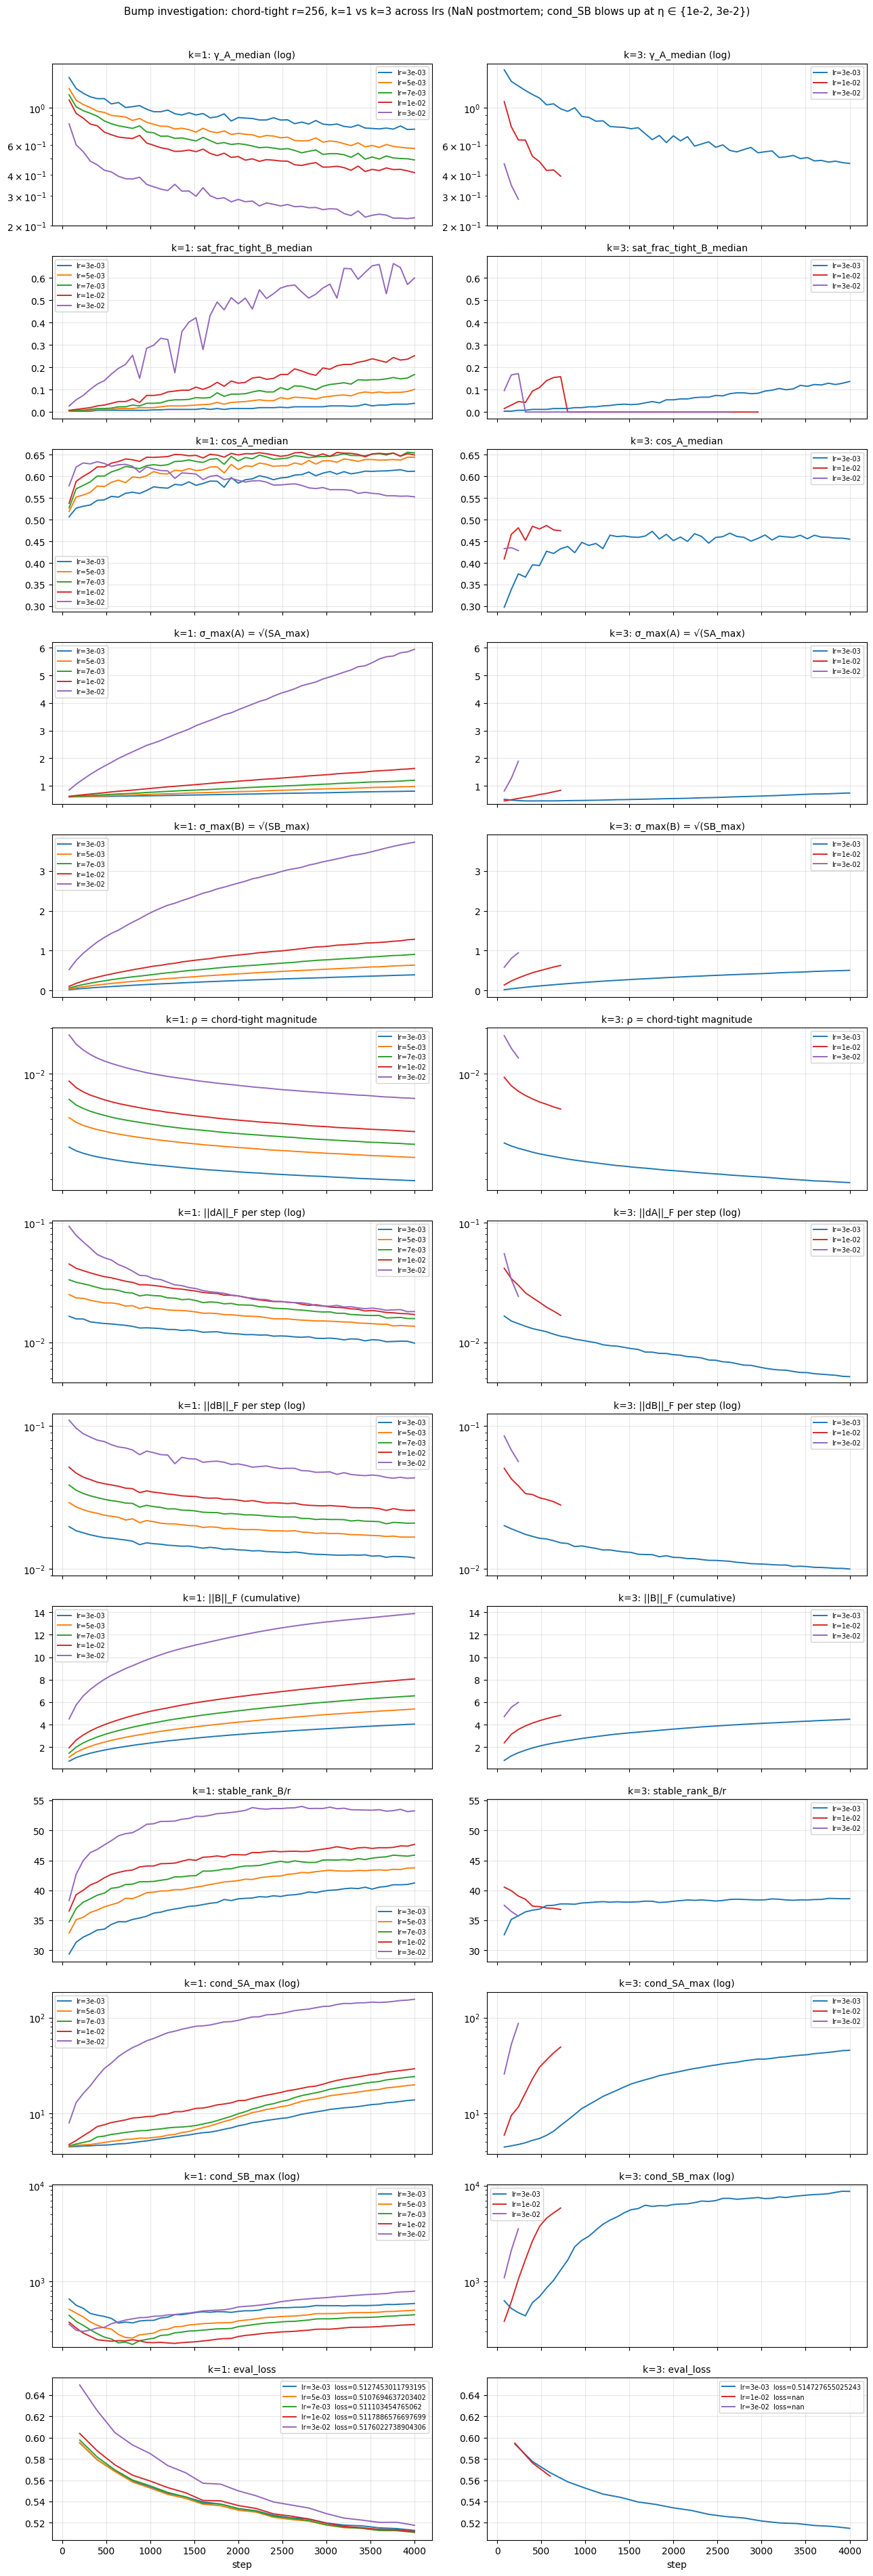

In [58]:
# Mirror of the r=64 plot cell with r=256 data. Same PANEL_METRICS list
# (including cond_SA_max / cond_SB_max), same lr palette, same row-shared
# y-limits. Exact-chord overlay only fires if EXACT_K3_R256[5e-3] exists.

ALL_LRS_256 = sorted(set(K1_R256) | set(K3_R256))
_LR_COLOR_256 = {lr: _palette[i % len(_palette)] for i, lr in enumerate(ALL_LRS_256)}
def lr_color_256(lr): return _LR_COLOR_256[lr]

fig, axes = plt.subplots(len(PANEL_METRICS), 2, figsize=(13, 4 + 2.6 * len(PANEL_METRICS)), sharex=True)
for col, (k_label, K_DATA) in enumerate([('k=1', K1_R256), ('k=3', K3_R256)]):
    for row, (title, key, yscale, ylog, transform) in enumerate(PANEL_METRICS):
        ax = axes[row, col]
        for lr in sorted(K_DATA):
            d = K_DATA[lr]
            if key == '__eval__':
                xs, ys = eval_series(d)
            elif key == '__rho__':
                xs, ys = rho_series(d, lr)
            else:
                xs, ys = diag_series(d, key)
            if len(xs) == 0:
                continue
            if key == '__eval__':
                final = K_DATA[lr]['evs'][-1]['eval_loss']
                lbl = f'lr={lr:.0e}  loss={final}'
            else:
                lbl = f'lr={lr:.0e}'
            ax.plot(xs, ys, color=lr_color_256(lr), label=lbl, lw=1.4)
        # Overlay exact-chord variant on the k=3 column at lr=5e-3 (if present)
        if col == 1 and 5e-3 in EXACT_K3_R256:
            d = EXACT_K3_R256[5e-3]
            if key == '__eval__':
                xs, ys = eval_series(d)
            elif key == '__rho__':
                xs, ys = rho_series(d, lr)
            else:
                xs, ys = diag_series(d, key)
            if len(xs):
                ax.plot(xs, ys, color='#d62728', ls='--', lw=2.0,
                        label=(f'exact lr=5e-3  loss={EXACT_K3_R256[5e-3]["evs"][-1]["eval_loss"]} @step{EXACT_K3_R256[5e-3]["evs"][-1]["step"]}' if key == '__eval__' else 'exact lr=5e-3'), marker='x', markersize=4)
        ax.set_yscale(yscale)
        ax.set_title(f'{k_label}: {title}', fontsize=10)
        ax.grid(alpha=0.3)
        if row == len(PANEL_METRICS) - 1:
            ax.set_xlabel('step')
        ax.legend(loc='best', fontsize=7, ncol=1, frameon=True, framealpha=0.85)

for row, (_, _, yscale, _, _) in enumerate(PANEL_METRICS):
    if yscale == 'log':
        lo = min(axes[row, 0].get_ylim()[0], axes[row, 1].get_ylim()[0])
        hi = max(axes[row, 0].get_ylim()[1], axes[row, 1].get_ylim()[1])
        axes[row, 0].set_ylim(lo, hi)
        axes[row, 1].set_ylim(lo, hi)
    else:
        lo0, hi0 = axes[row, 0].get_ylim()
        lo1, hi1 = axes[row, 1].get_ylim()
        axes[row, 0].set_ylim(min(lo0, lo1), max(hi0, hi1))
        axes[row, 1].set_ylim(min(lo0, lo1), max(hi0, hi1))

fig.suptitle(f'Bump investigation: chord-tight r={BUMP_R_256}, k=1 vs k=3 across lrs '
             '(NaN postmortem; cond_SB blows up at η ∈ {1e-2, 3e-2})',
             fontsize=11, y=1.005)
plt.tight_layout()
plt.show()
